# ALICE, walked through: a 1D + 1D mutual-information example

This notebook follows the paper's inference story with scalar variables $X$ and $Y$. We will
build the exact rectified-flow velocity field for a correlated Gaussian, use three masks to
turn one field into the joint and conditional fields, and read mutual information from their
velocity gaps.

The notebook uses a local ALICE checkpoint when available and otherwise loads it from
Hugging Face. The analytic Gaussian field is the reference, and the trained model is evaluated
on the same grid and with the same masks so their vector fields and conditional slices can be compared directly before estimating MI.

## The one sentence to remember

The **context** $C=\{z^{(k)}\}_{k=1}^{n}$ is a collection of $n$ clean joint samples that tells
ALICE *which distribution* to represent. The **query** tells it *where* to evaluate the
velocity field. The noising indicator $m\in\{0,1\}^{2}$ says which coordinates are noised
($m[j]=1$) and which are held clean as evidence ($m[j]=0$).

The paper uses the rectified-flow convention $t=0$ for clean data and $t=1$ for Gaussian
noise. Its context-conditioned model is written $v_\theta(z,t,m;C)$, where $\theta$ denotes
the frozen model parameters.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch

from tueplots import bundles, cycler
from tueplots.constants.color import palettes

# Use the same publication-oriented configuration family as the paper figures.
plt.rcParams.update(bundles.iclr2024(rel_width=0.95, ncols=1, family='sans serif'))
plt.rcParams.update({
    'text.usetex': False,
    'figure.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'grid.alpha': 0.22,
})
plt.rcParams.update(cycler.cycler(color=palettes.paultol_bright))

COLORS = {
    'context': "#2E75C7",
    'query': '#CC7711',
    'noise': '#8844AA',
    'clean': '#117733',
    'field': '#4477AA',
    'conditional': '#CC3311',
    'error': '#AA3377',
}

SEED = 17
torch.set_default_dtype(torch.float64)
torch.manual_seed(SEED)
np.random.seed(SEED)
print('PyTorch:', torch.__version__)

PyTorch: 2.14.0


## 1. A concrete 1D + 1D distribution

Let $Z=(X,Y)$ be a zero-mean Gaussian with unit marginal variances and correlation $\rho$.
For this example the true mutual information is known exactly:

$$I(X;Y)=-\frac{1}{2}\log\left(1-\rho^2\right)\quad\text{nats}. $$

The sample cloud below illustrates the joint distribution that a clean context represents.

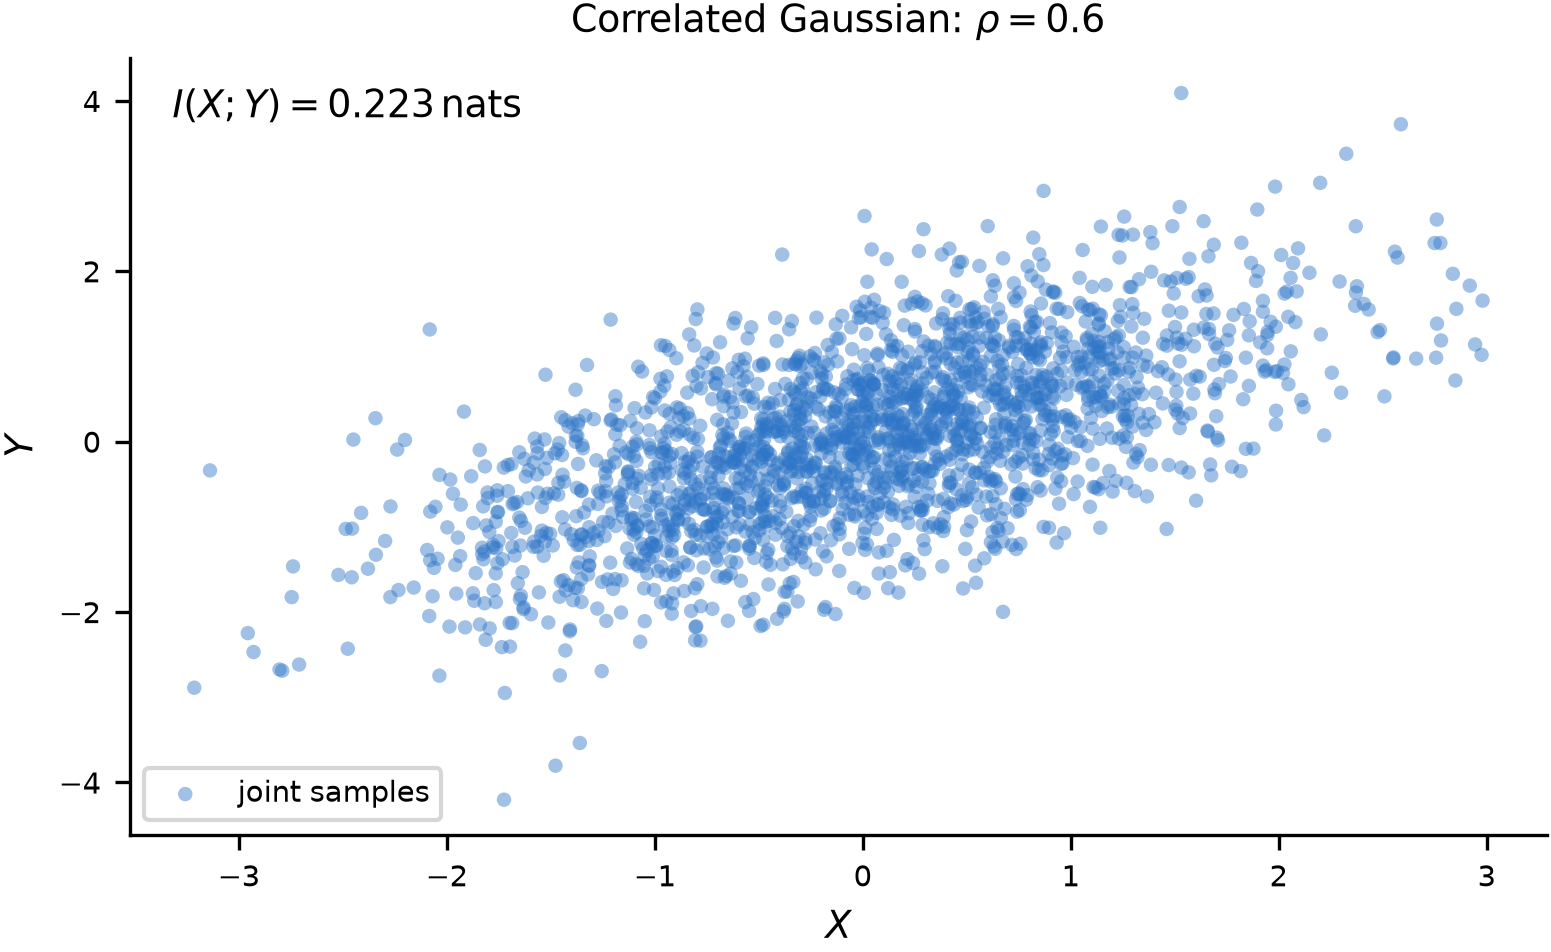

In [2]:
rho = 0.6
sigma = torch.tensor([[1.0, rho], [rho, 1.0]])
chol = torch.linalg.cholesky(sigma)
sample_generator = torch.Generator().manual_seed(SEED)
samples = torch.randn((2048, 2), generator=sample_generator) @ chol.T
true_mi = -0.5 * math.log1p(-rho**2)

fig, ax = plt.subplots()
ax.scatter(samples[:, 0], samples[:, 1], s=12, alpha=0.45, color=COLORS['context'],
           edgecolors='none', label='joint samples')
ax.set(xlabel=r'$X$', ylabel=r'$Y$', title=fr'Correlated Gaussian: $\rho = {rho:.1f}$')
ax.legend()
ax.text(0.03, 0.96, fr'$I(X;Y) = {true_mi:.3f}\,\mathrm{{nats}}$',
        transform=ax.transAxes, va='top')
plt.show()

## 2. The exact rectified-flow velocity field

Let $z_0=(x_0,y_0)\sim p_{XY}$ be a clean joint sample, and let
$\epsilon=(\epsilon_X,\epsilon_Y)\sim\mathcal{N}(0,I)$ be independent standard Gaussian noise.
The forward process linearly interpolates between the clean point and noise:

$$x_t=(1-t)x_0+t\epsilon_X,\qquad y_t=(1-t)y_0+t\epsilon_Y,\qquad z_t=(x_t,y_t).$$

The joint velocity field is the conditional average
$v_t(z)=\mathbb{E}[z_0-\epsilon\mid z_t=z]$. This is the direction toward clean data, the
negative of the forward interpolant's derivative. For this Gaussian example it is available
in closed form. If $\Sigma$ is the covariance of $z_0$ and $I$ is the $2\times2$ identity
matrix, then the row-vector implementation below evaluates

$$v_t(z)=\left((1-t)\Sigma-tI\right)\left((1-t)^2\Sigma+t^2I\right)^{-1}z.$$

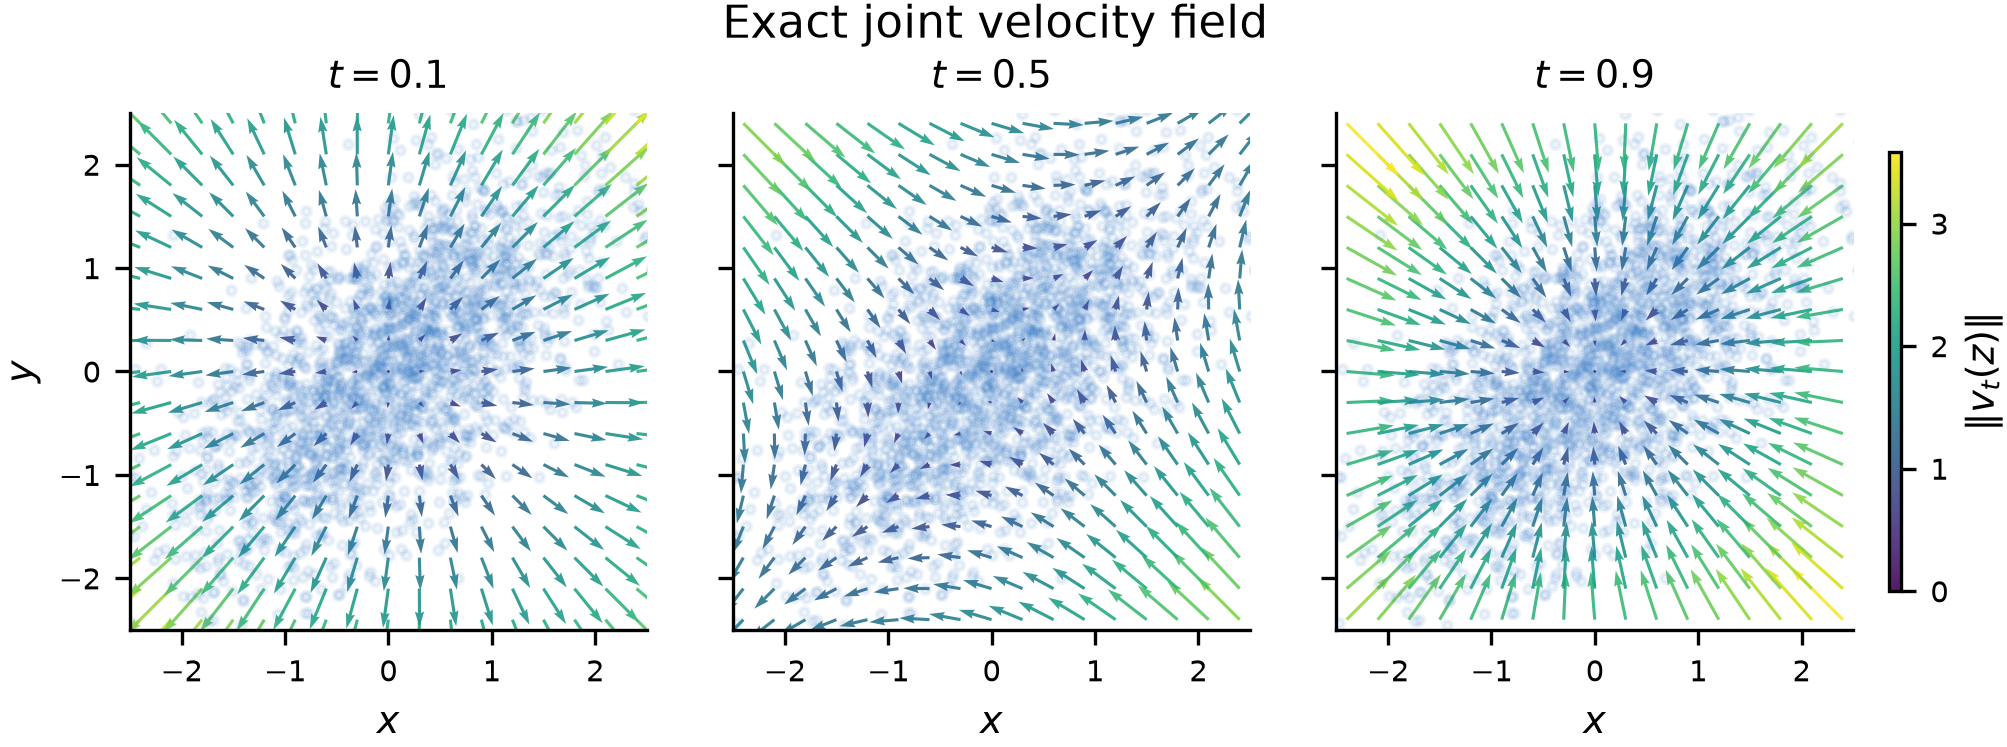

In [3]:
def covariance(rho_value):
    return torch.tensor([[1.0, rho_value], [rho_value, 1.0]])


def exact_joint_velocity(z, t, rho_value):
    z = torch.as_tensor(z)
    sigma_value = covariance(rho_value).to(dtype=z.dtype, device=z.device)
    eye = torch.eye(2, dtype=z.dtype, device=z.device)
    a = 1.0 - float(t)
    operator = (a * sigma_value - float(t) * eye) @ torch.linalg.inv(
        a * a * sigma_value + float(t) * float(t) * eye
    )
    return z @ operator.T


def exact_conditional_velocity(q, t, condition, rho_value):
    # q is the noised scalar; condition is the other clean scalar.
    q = torch.as_tensor(q)
    condition = torch.as_tensor(condition, dtype=q.dtype, device=q.device)
    variance = 1.0 - rho_value * rho_value
    mean = rho_value * condition
    a = 1.0 - float(t)
    denominator = a * a * variance + float(t) * float(t)
    slope = (a * variance - float(t)) / denominator
    return mean + slope * (q - a * mean)


def grid_points(limit=2.4, steps=17):
    axis = torch.linspace(-limit, limit, steps)
    xx, yy = torch.meshgrid(axis, axis, indexing='xy')
    points = torch.stack((xx.reshape(-1), yy.reshape(-1)), dim=-1)
    return axis, xx, yy, points


axis, xx, yy, grid = grid_points()
time_slices = (0.1, 0.5, 0.9)
exact_fields = [exact_joint_velocity(grid, t_value, rho).reshape(xx.shape + (2,))
                for t_value in time_slices]
exact_speeds = [torch.linalg.vector_norm(velocity, dim=-1) for velocity in exact_fields]
field_scale = max(float(torch.stack(exact_speeds).max()), 0.5)

fig, axes = plt.subplots(1, 3, figsize=(7, 2.5), sharex=True, sharey=True,
                         layout='constrained')
for ax, t_value, velocity, speed in zip(axes, time_slices, exact_fields, exact_speeds):
    arrows = ax.quiver(xx, yy, velocity[..., 0], velocity[..., 1], speed,
                       cmap='viridis', angles='xy',
                       scale_units='xy', scale=5, alpha=0.9, width=0.006)
    arrows.set_clim(0, field_scale)
    ax.scatter(samples[:, 0], samples[:, 1], s=5, alpha=0.08, color=COLORS['context'])
    ax.set(xlim=(-2.5, 2.5), ylim=(-2.5, 2.5), xlabel=r'$x$',
           title=fr'$t = {t_value:.1f}$')
    ax.set_aspect('equal')
axes[0].set_ylabel(r'$y$')
fig.colorbar(arrows, ax=axes, label=r'$\|v_t(z)\|$', shrink=0.85,
             fraction=0.03, pad=0.02, aspect=35)
fig.suptitle('Exact joint velocity field')
plt.show()

The joint field $v_t(z)$ is two-dimensional, but the conditional fields are one-dimensional
in this 1D + 1D example. Holding $Y=y_0$ clean gives $v_t(x\mid y_0)$, the field of
$p_{X\mid Y=y_0}$ evaluated at $x$; holding $X=x_0$ clean gives $v_t(y\mid x_0)$.
For a concatenated vector $u=(u_X,u_Y)$, the selections $u|_X$ and $u|_Y$ retain the
corresponding blocks. The next plot compares the conditional fields with slices of
$v_t(z)|_X$ and $v_t(z)|_Y$.

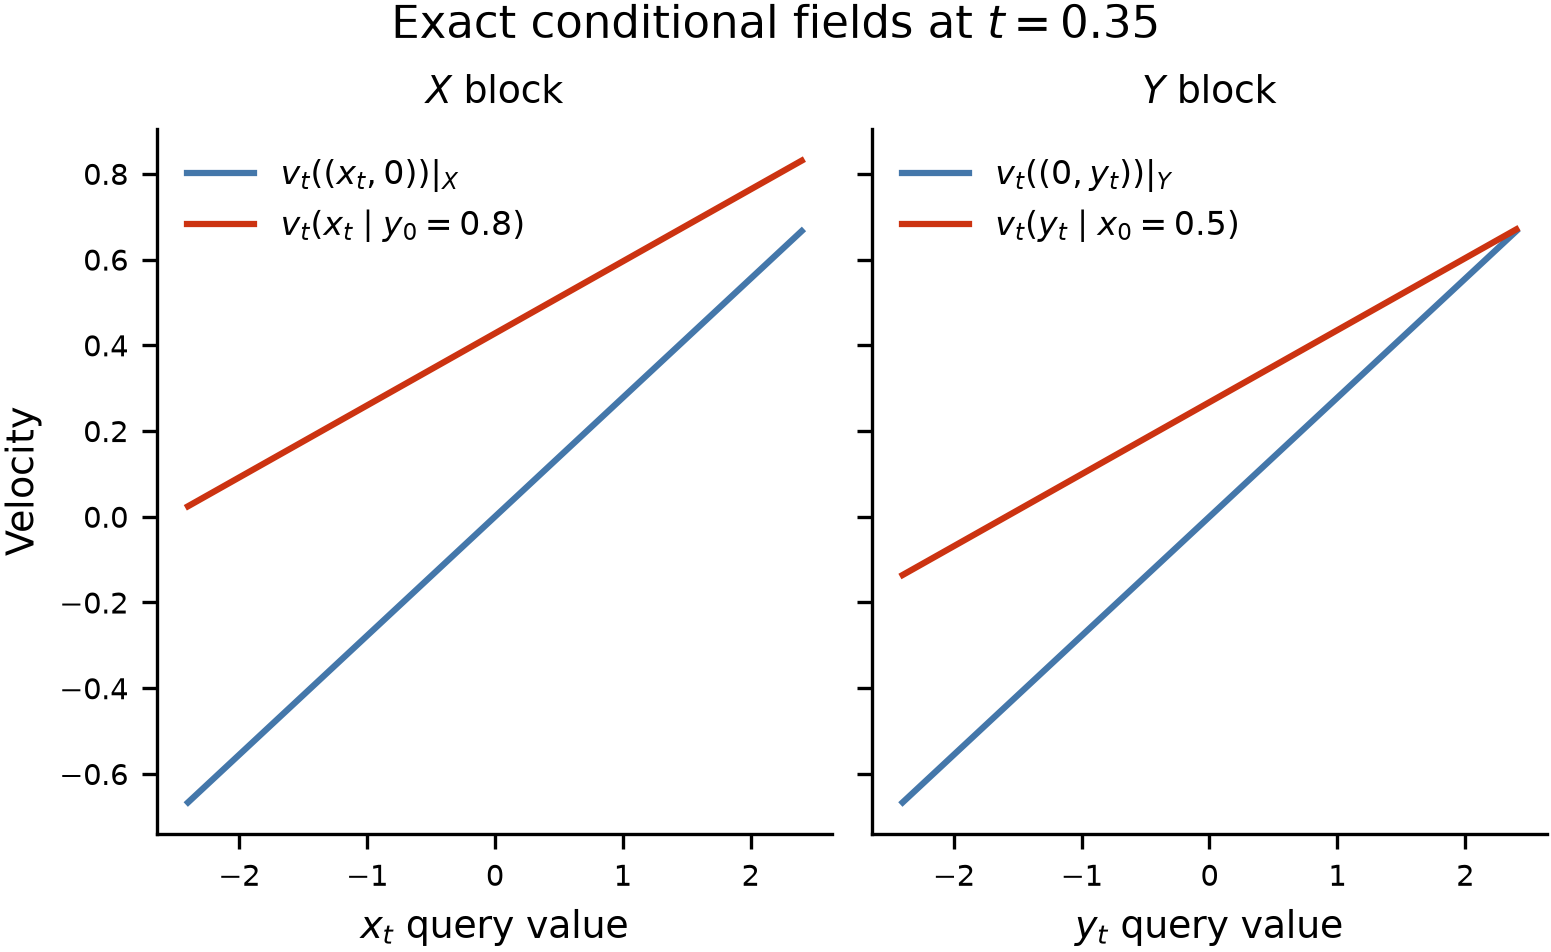

In [4]:
t_slice = 0.35
y0_condition = 0.8
x0_condition = 0.5
scalar_grid = torch.linspace(-2.4, 2.4, 300)
joint_x_slice = exact_joint_velocity(
    torch.stack((scalar_grid, torch.zeros_like(scalar_grid)), dim=-1), t_slice, rho
)[:, 0]
joint_y_slice = exact_joint_velocity(
    torch.stack((torch.zeros_like(scalar_grid), scalar_grid), dim=-1), t_slice, rho
)[:, 1]
conditional_x = exact_conditional_velocity(scalar_grid, t_slice, y0_condition, rho)
conditional_y = exact_conditional_velocity(scalar_grid, t_slice, x0_condition, rho)

fig, axes = plt.subplots(1, 2, sharey=True, layout='constrained')
axes[0].plot(scalar_grid, joint_x_slice, color=COLORS['field'], label=r'$v_t((x_t,0))|_X$')
axes[0].plot(scalar_grid, conditional_x, color=COLORS['conditional'],
              label=fr'$v_t(x_t\mid y_0={y0_condition:.1f})$')
axes[0].set(xlabel=r'$x_t$ query value', ylabel='Velocity', title=r'$X$ block')
axes[0].legend(frameon=False, fontsize=8)
axes[1].plot(scalar_grid, joint_y_slice, color=COLORS['field'], label=r'$v_t((0,y_t))|_Y$')
axes[1].plot(scalar_grid, conditional_y, color=COLORS['conditional'],
              label=fr'$v_t(y_t\mid x_0={x0_condition:.1f})$')
axes[1].set(xlabel=r'$y_t$ query value', title=r'$Y$ block')
axes[1].legend(frameon=False, fontsize=8)
fig.suptitle(fr'Exact conditional fields at $t = {t_slice:.2f}$')
plt.show()

## 3. One noisy point, three masked questions

For one clean sample $z_0$ we draw one $\epsilon$ and one $t$. The same noise realization is
shared by all three queries. Only the noising indicator and the corresponding query
coordinates change. The three evaluations compare the joint prediction with both
conditional predictions at the same time and the same noised coordinate in each block.

| Noising indicator | Query | Field represented on the noised block(s) |
| --- | --- | --- |
| $m_{XY}=(1,1)$ | $z_t=(x_t,y_t)$ | $v_t(z_t)$ |
| $m_X=(1,0)$ | $(x_t,y_0)$ | $v_t(x_t\mid y_0)$ |
| $m_Y=(0,1)$ | $(x_0,y_t)$ | $v_t(y_t\mid x_0)$ |

Reusing the noise makes the squared velocity gaps measure the effect of revealing the
other coordinate, rather than differences caused by unrelated random draws. These three
evaluations provide both block-wise gaps that the MI estimator integrates.

In [5]:
z0 = torch.tensor([0.70, 0.50])
epsilon = torch.tensor([-1.20, 0.40])
t_demo = 0.30
z_t = (1.0 - t_demo) * z0 + t_demo * epsilon

queries = {
    'joint': z_t,
    'X | Y': torch.tensor([z_t[0], z0[1]]),
    'Y | X': torch.tensor([z0[0], z_t[1]]),
}
m_xy = torch.tensor([1.0, 1.0])
m_x = torch.tensor([1.0, 0.0])
m_y = torch.tensor([0.0, 1.0])
print(f'z_0 = {z0.tolist()}')
print(f'epsilon = {epsilon.tolist()}')
print(f't = {t_demo}, z_t = {z_t.tolist()}')
for name, query in queries.items():
    print(f'{name:>6}: query = {query.tolist()}')
print('mask convention: 1 = coordinate is noised; 0 = coordinate is held clean')
for name, mask in zip(('m_XY', 'm_X', 'm_Y'), (m_xy, m_x, m_y)):
    print(f'{name:>6} = {mask.tolist()}')

z_0 = [0.7, 0.5]
epsilon = [-1.2, 0.4]
t = 0.3, z_t = [0.12999999999999995, 0.47]
 joint: query = [0.12999999999999995, 0.47]
 X | Y: query = [0.12999999999999995, 0.5]
 Y | X: query = [0.7, 0.47]
mask convention: 1 = coordinate is noised; 0 = coordinate is held clean
  m_XY = [1.0, 1.0]
   m_X = [1.0, 0.0]
   m_Y = [0.0, 1.0]


## 4. MI is the weighted velocity-gap integral

At each $(z_0,\epsilon,t)$ we compare the joint field with the matching conditional field
on the block that was noised. The paper's identity includes an expectation over the clean
sample and the shared Gaussian perturbation:

$$
I(X;Y)=\int_0^1\frac{1-t}{t}\,
\mathbb{E}_{x_0,y_0,\epsilon}\!\left[
\left\|v_t(z_t)|_X-v_t(x_t\mid y_0)\right\|^2
+\left\|v_t(z_t)|_Y-v_t(y_t\mid x_0)\right\|^2
\right]\,\mathrm{d}t.
$$

Here each block is scalar, so the squared norms reduce to squared differences. We denote
the entire weighted expectation by $\mathcal{I}(t)$ in the plots. The code below averages
over sampled $(z_0,\epsilon)$ pairs and approximates the time integral on a fixed grid.

closed-form MI: 0.2231 nats
velocity-gap integral on this finite grid: 0.2259 nats


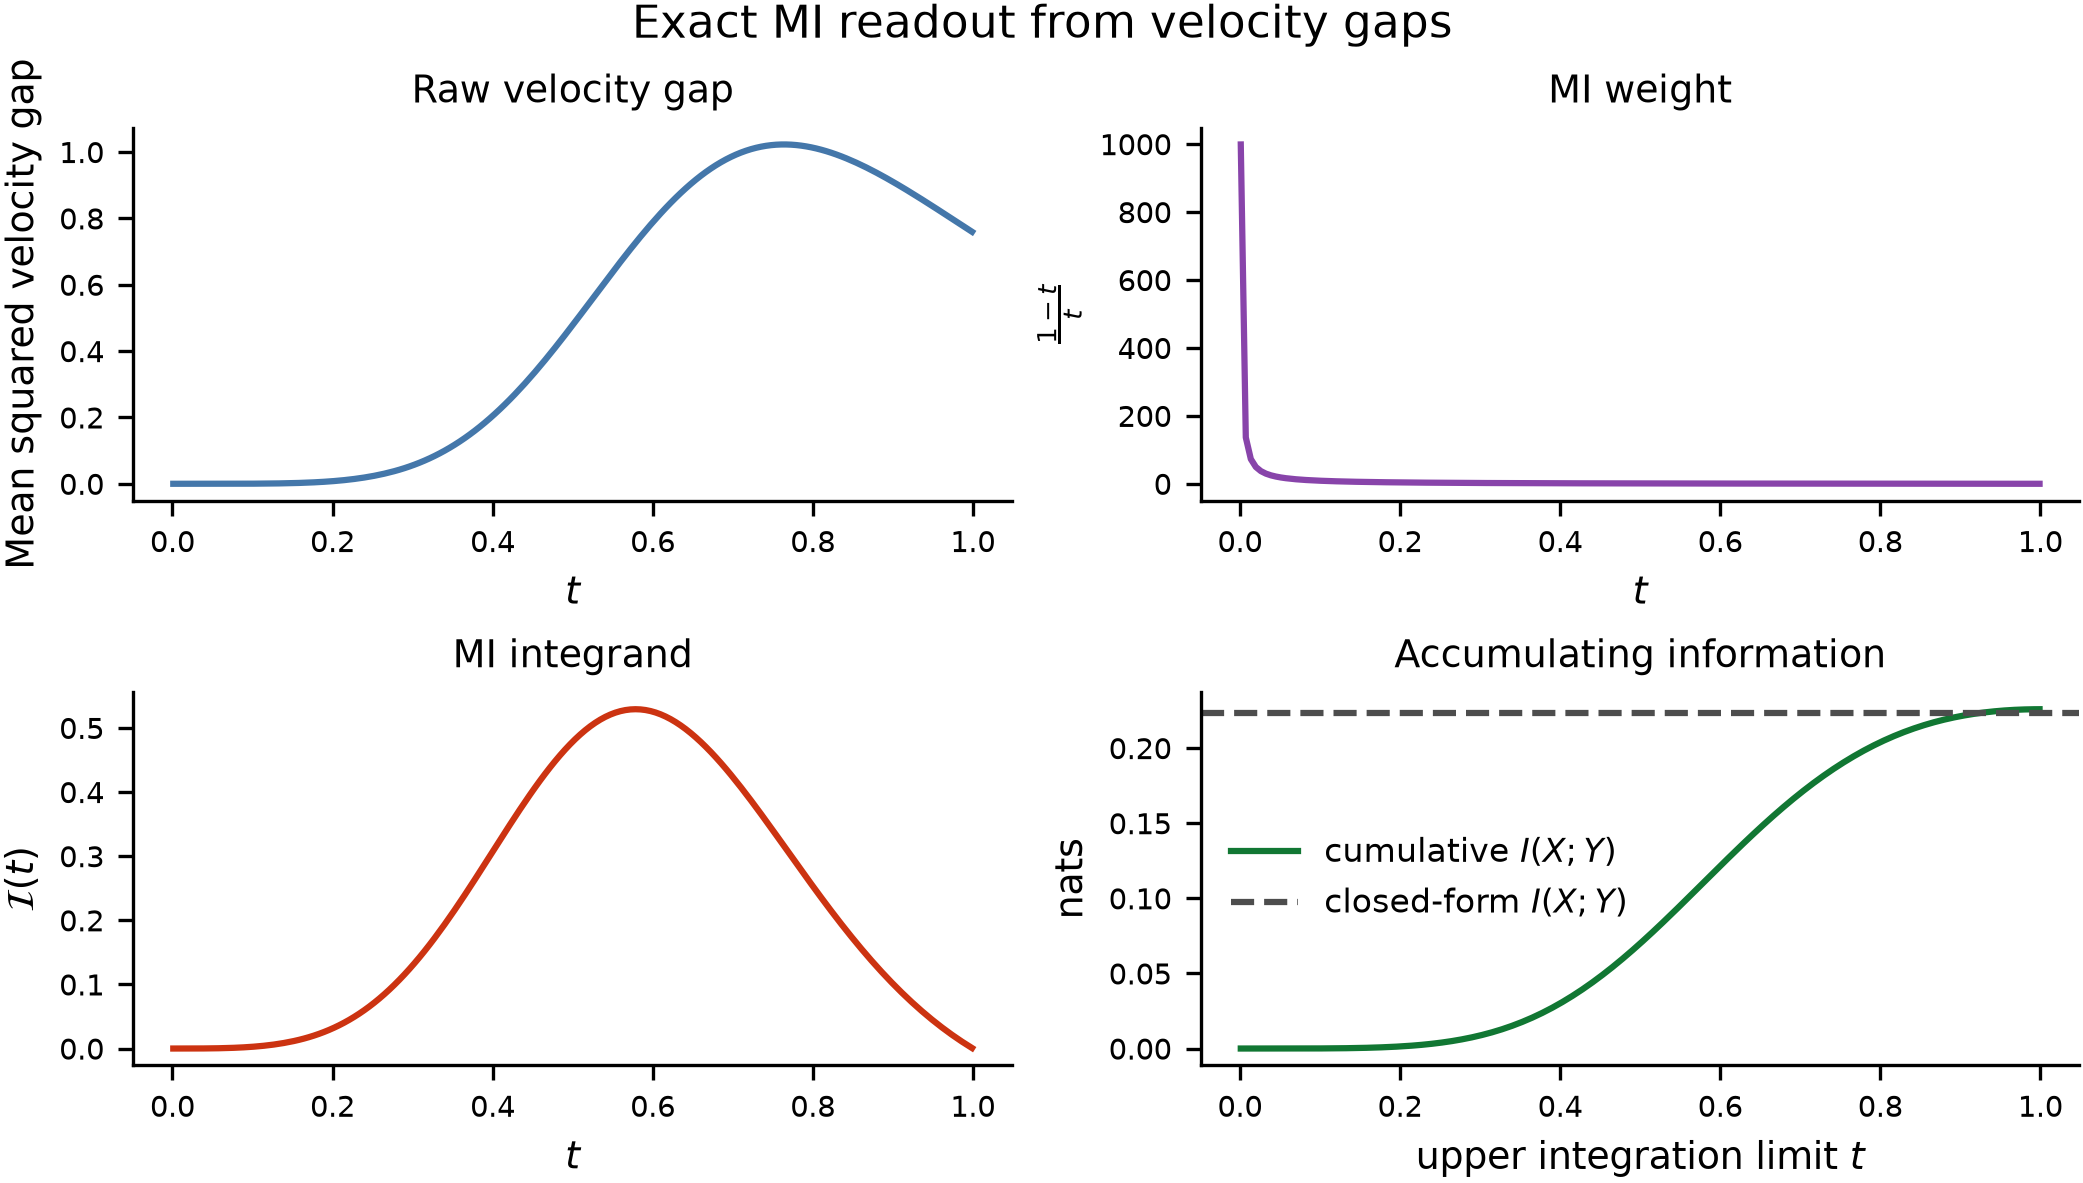

In [6]:
def exact_gap_curves(t_grid, z0_values, epsilon_values, rho_value):
    gap_values = []
    for t_value in t_grid:
        t_column = torch.full((z0_values.shape[0], 1), float(t_value))
        z_full = (1.0 - t_column) * z0_values + t_column * epsilon_values
        z_x = z0_values.clone()
        z_x[:, 0] = z_full[:, 0]
        z_y = z0_values.clone()
        z_y[:, 1] = z_full[:, 1]
        v_full = exact_joint_velocity(z_full, t_value, rho_value)
        v_x = torch.stack((exact_conditional_velocity(z_full[:, 0], t_value, z0_values[:, 1], rho_value),
                           torch.zeros_like(z_full[:, 1])), dim=-1)
        v_y = torch.stack((torch.zeros_like(z_full[:, 0]),
                           exact_conditional_velocity(z_full[:, 1], t_value, z0_values[:, 0], rho_value)), dim=-1)
        gap = (v_full[:, 0] - v_x[:, 0]).square() + (v_full[:, 1] - v_y[:, 1]).square()
        gap_values.append(gap.mean())
    gaps = torch.stack(gap_values)
    weights = (1.0 - t_grid) / t_grid
    return gaps, weights, gaps * weights


def cumulative_trapezoid(x, y):
    increments = 0.5 * (y[1:] + y[:-1]) * (x[1:] - x[:-1])
    return torch.cat((torch.zeros(1), torch.cumsum(increments, dim=0)))

eval_generator = torch.Generator().manual_seed(SEED + 1)
eval_z0 = torch.randn((512, 2), generator=eval_generator) @ chol.T
eval_epsilon = torch.randn((512, 2), generator=eval_generator)
t_grid = torch.linspace(0.001, 0.999, 160)
gaps, weights, integrand = exact_gap_curves(t_grid, eval_z0, eval_epsilon, rho)
cumulative_mi = cumulative_trapezoid(t_grid, integrand)
mi_from_grid = torch.trapezoid(integrand, t_grid).item()
print(f'closed-form MI: {true_mi:.4f} nats')
print(f'velocity-gap integral on this finite grid: {mi_from_grid:.4f} nats')

fig, axes = plt.subplots(2, 2, figsize=(7, 4), layout='constrained')
axes[0, 0].plot(t_grid, gaps, color=COLORS['field'])
axes[0, 0].set(xlabel=r'$t$', ylabel='Mean squared velocity gap',
                   title='Raw velocity gap')
axes[0, 1].plot(t_grid, weights, color=COLORS['noise'])
axes[0, 1].set(xlabel=r'$t$', ylabel=r'$\frac{1-t}{t}$', title='MI weight')
axes[1, 0].plot(t_grid, integrand, color=COLORS['conditional'])
axes[1, 0].set(xlabel=r'$t$', ylabel=r'$\mathcal{I}(t)$', title='MI integrand')
axes[1, 1].plot(t_grid, cumulative_mi, color=COLORS['clean'],
                    label=r'cumulative $I(X;Y)$')
axes[1, 1].axhline(true_mi, color='0.3', ls='--',
                    label=r'closed-form $I(X;Y)$')
axes[1, 1].set(xlabel=r'upper integration limit $t$', ylabel=r'$\mathrm{nats}$',
                   title='Accumulating information')
axes[1, 1].legend(frameon=False, fontsize=8)
fig.suptitle('Exact MI readout from velocity gaps')
plt.show()

## 5. Compare the exact field with trained ALICE

Let's work on the real ALICE!

The model is bound to the finite context $C$ and evaluated on the same grid and masks used
above. The callable `field(query, t, m)` evaluates
$v_\theta(\mathrm{query},t,m;C)$. At any shared draw $(z_0,\epsilon,t)$, the three predictions
are written

$$
\widehat v=v_\theta(z_t,t,m_{XY};C),\qquad
\widehat v_X=v_\theta((x_t,y_0),t,m_X;C),\qquad
\widehat v_Y=v_\theta((x_0,y_t),t,m_Y;C).
$$

The subscripts on $\widehat v_X$ and $\widehat v_Y$ identify the noising indicators;
$|_X$ and $|_Y$ select output blocks. Each prediction is approximate because it is
conditioned on a finite context and comes from a frozen model trained across distributions.

With $N_{\mathrm{MC}}$ draws and $t_i\sim\mathcal{U}[0,1]$, the paper's Monte Carlo estimator is

$$
\widehat I(X;Y)=\frac{1}{N_{\mathrm{MC}}}\sum_{i=1}^{N_{\mathrm{MC}}}\frac{1-t_i}{t_i}
\left[
\left\|(\widehat v^{(i)}-\widehat v_X^{(i)})|_X\right\|^2
+\left\|(\widehat v^{(i)}-\widehat v_Y^{(i)})|_Y\right\|^2
\right].
$$

The superscript $(i)$ indexes a shared draw of the clean sample, time, and noise. In the
public API call below, $N_{\mathrm{MC}}$ equals `n_eval * n_t_samples`.

The conditional-field figure shows one-dimensional slices at a fixed time. The left panel
varies $x_t$ and the right panel varies $y_t$. Solid curves are the analytic Gaussian
reference and dashed curves are ALICE predictions. The blue curves use $m_{XY}$ with the
other noised coordinate fixed at zero. The red curves use $m_X$ or $m_Y$ with the other
clean coordinate fixed at $\texttt{condition}$. These slices illustrate the block-wise
comparisons; the MI calculation below evaluates them along shared sample and noise draws.

We use 4,096 clean context samples and 1,024 evaluation samples. The final cell prints the
ALICE estimate with its Monte Carlo standard error.
The reported standard error does not include finite-context or model error.
We use `estimate_mi_fast`, which caches context and attention
projections and batches the three masked fields with their boundary corrections.

In [19]:
from pathlib import Path

from alice import estimate_mi_fast, load_model, velocity_field_masked

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

model_name = 'alice-small-stage2'
local_candidates = (Path('models') / model_name, Path('../models') / model_name)
local_model = next(
    (path for path in local_candidates
     if (path / 'config.json').is_file() and (path / 'model.safetensors').is_file()),
    None,
)
model_source = str(local_model.resolve()) if local_model else f'eurecom-probai/{model_name}'
print(f'Model source: {model_source}')
print(f'Inference device: {device}')
# Float32 model inference is supported on CUDA, MPS, and CPU.
model = load_model(model_source, device=device, dtype=torch.float32)
n_context = 4096
n_eval = 1024
context_generator = torch.Generator().manual_seed(SEED)
model_samples = (torch.randn((n_context, 2), generator=context_generator) @ chol.T).float()
context = model_samples
evaluation_generator = torch.Generator().manual_seed(SEED + 2)
evaluation_samples = torch.randn((n_eval, 2), generator=evaluation_generator).float() @ chol.float().T
field = velocity_field_masked(model, context, device=device, chunk=256)
print(f'loaded {type(model).__name__} with context C of shape {tuple(context.shape)}')
print('The model is frozen; all following values are forward-pass field evaluations.')

Model source: eurecom-probai/alice-small-stage2
Inference device: mps


Loading weights: 100%|██████████| 183/183 [00:00<00:00, 21468.94it/s]

loaded InducedGroupICLDenoiserModel with context C of shape (4096, 2)
The model is frozen; all following values are forward-pass field evaluations.


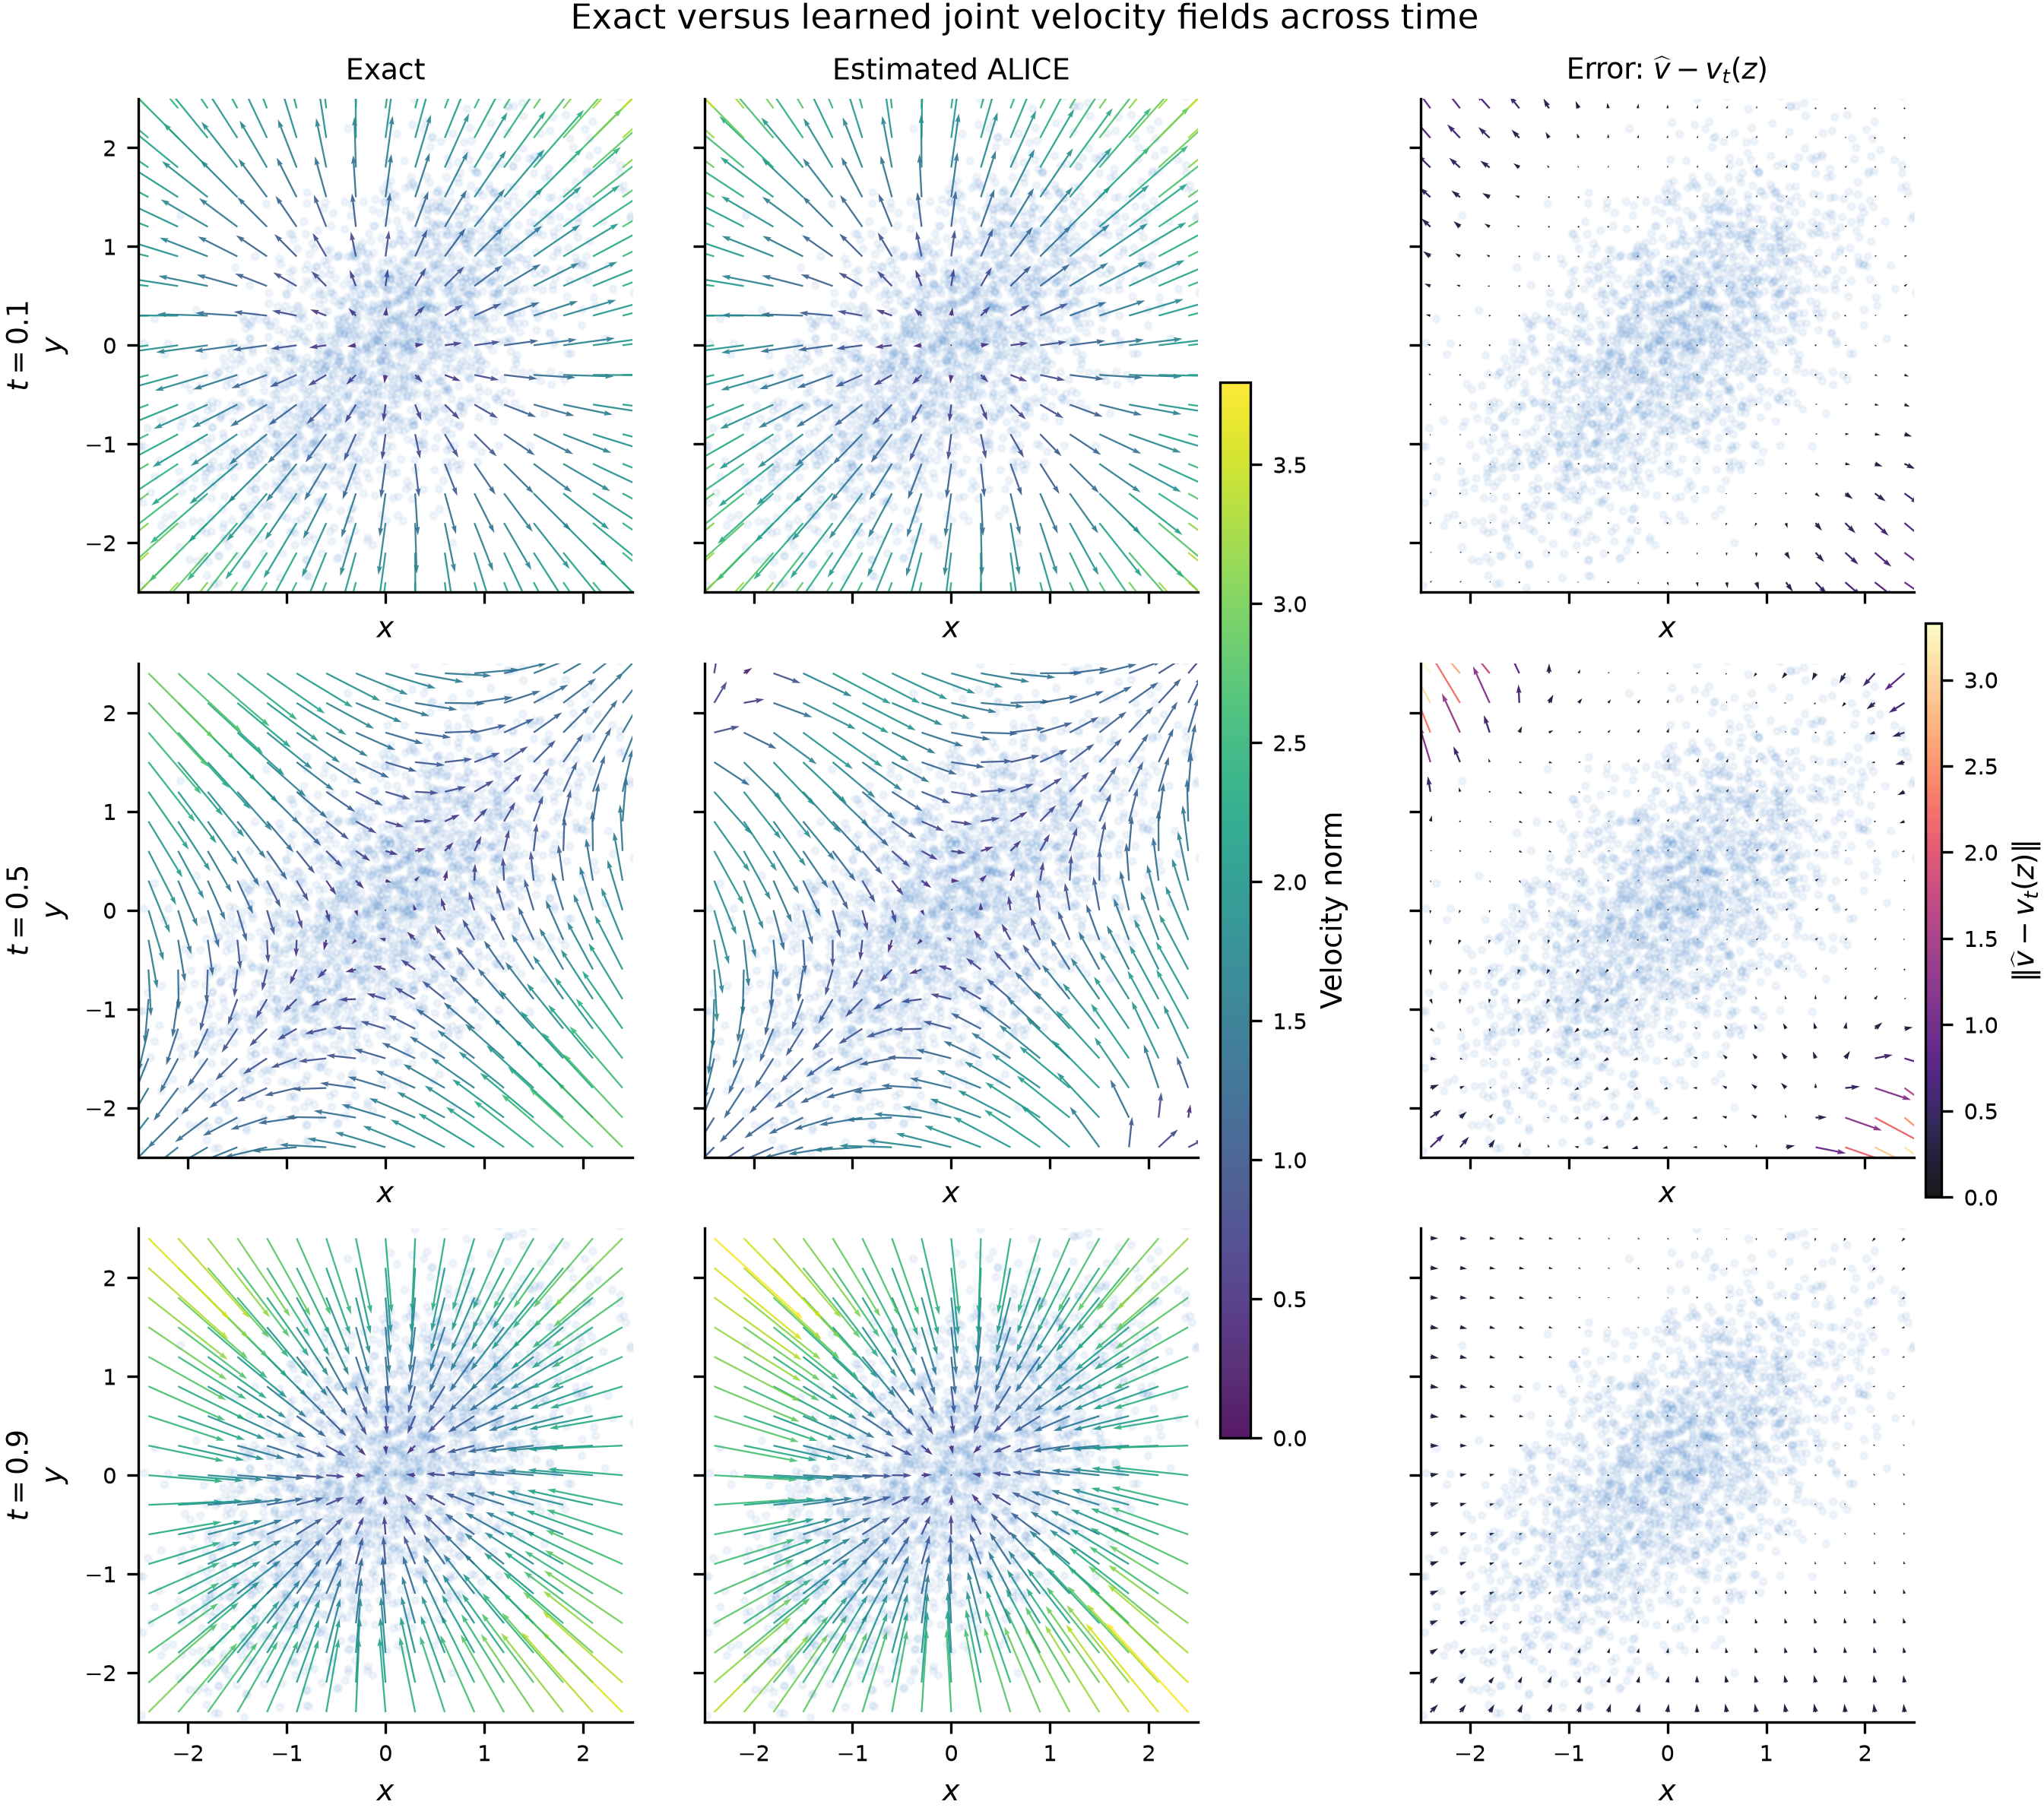

mean vector-field errors: [0.11937226355075836, 0.2670252323150635, 0.12709373235702515]


In [20]:
comparison_times = time_slices
t_field = 0.6
model_grid = grid.float()
comparison_results = []
for t_value in comparison_times:
    model_velocity = field(
        model_grid,
        torch.full((model_grid.shape[0], 1), t_value, dtype=model_grid.dtype),
        m_xy,
    ).reshape(xx.shape + (2,))
    exact_velocity = exact_joint_velocity(grid, t_value, rho).reshape(xx.shape + (2,)).float()
    difference = model_velocity - exact_velocity
    comparison_results.append((exact_velocity, model_velocity, difference))

field_scale = max(float(torch.stack([
    torch.linalg.vector_norm(values, dim=-1)
    for exact_value, model_value, _ in comparison_results
    for values in (exact_value, model_value)
]).max()), 0.5)
error_scale = max(float(torch.stack([
    torch.linalg.vector_norm(difference, dim=-1)
    for _, _, difference in comparison_results
]).max()), 1e-6)

fig, axes = plt.subplots(3, 3, figsize=(9, 8), sharex=True, sharey=True,
                         layout='constrained')
column_specs = (
    ('Exact', 'viridis', field_scale),
    ('Estimated ALICE', 'viridis', field_scale),
    (r'Error: $\widehat{v}-v_t(z)$', 'magma', error_scale),
)
for row, (t_value, (exact_value, model_value, difference)) in enumerate(
        zip(comparison_times, comparison_results)):
    values_by_column = (exact_value, model_value, difference)
    for col, ((column_title, cmap, vmax), values) in enumerate(
            zip(column_specs, values_by_column)):
        magnitude = torch.linalg.vector_norm(values, dim=-1)
        arrows = axes[row, col].quiver(
            xx, yy, values[..., 0], values[..., 1], magnitude, cmap=cmap,
            angles='xy', scale_units='xy', scale=3.1, alpha=0.9
        )
        arrows.set_clim(0, vmax)
        axes[row, col].scatter(samples[:, 0], samples[:, 1], s=4, alpha=0.06,
                               color=COLORS['context'])
        axes[row, col].set(xlim=(-2.5, 2.5), ylim=(-2.5, 2.5), xlabel=r'$x$')
        axes[row, col].set_aspect('equal')
        if row == 0:
            axes[row, col].set_title(column_title)
        if col == 0:
            axes[row, col].set_ylabel(f'$t = {t_value:.1f}$\n$y$')
        if col < 2:
            field_arrows = arrows
        else:
            error_arrows = arrows
fig.colorbar(field_arrows, ax=axes[:, :2].ravel().tolist(), shrink=0.65,
             fraction=0.03, pad=0.02, aspect=35, label='Velocity norm')
fig.colorbar(error_arrows, ax=axes[:, 2].ravel().tolist(), shrink=0.65,
             fraction=0.03, pad=0.02, aspect=35,
             label=r'$\|\widehat{v}-v_t(z)\|$')
fig.suptitle('Exact versus learned joint velocity fields across time')
plt.show()
print('mean vector-field errors:', [
    float(torch.linalg.vector_norm(difference, dim=-1).mean())
    for _, _, difference in comparison_results
])

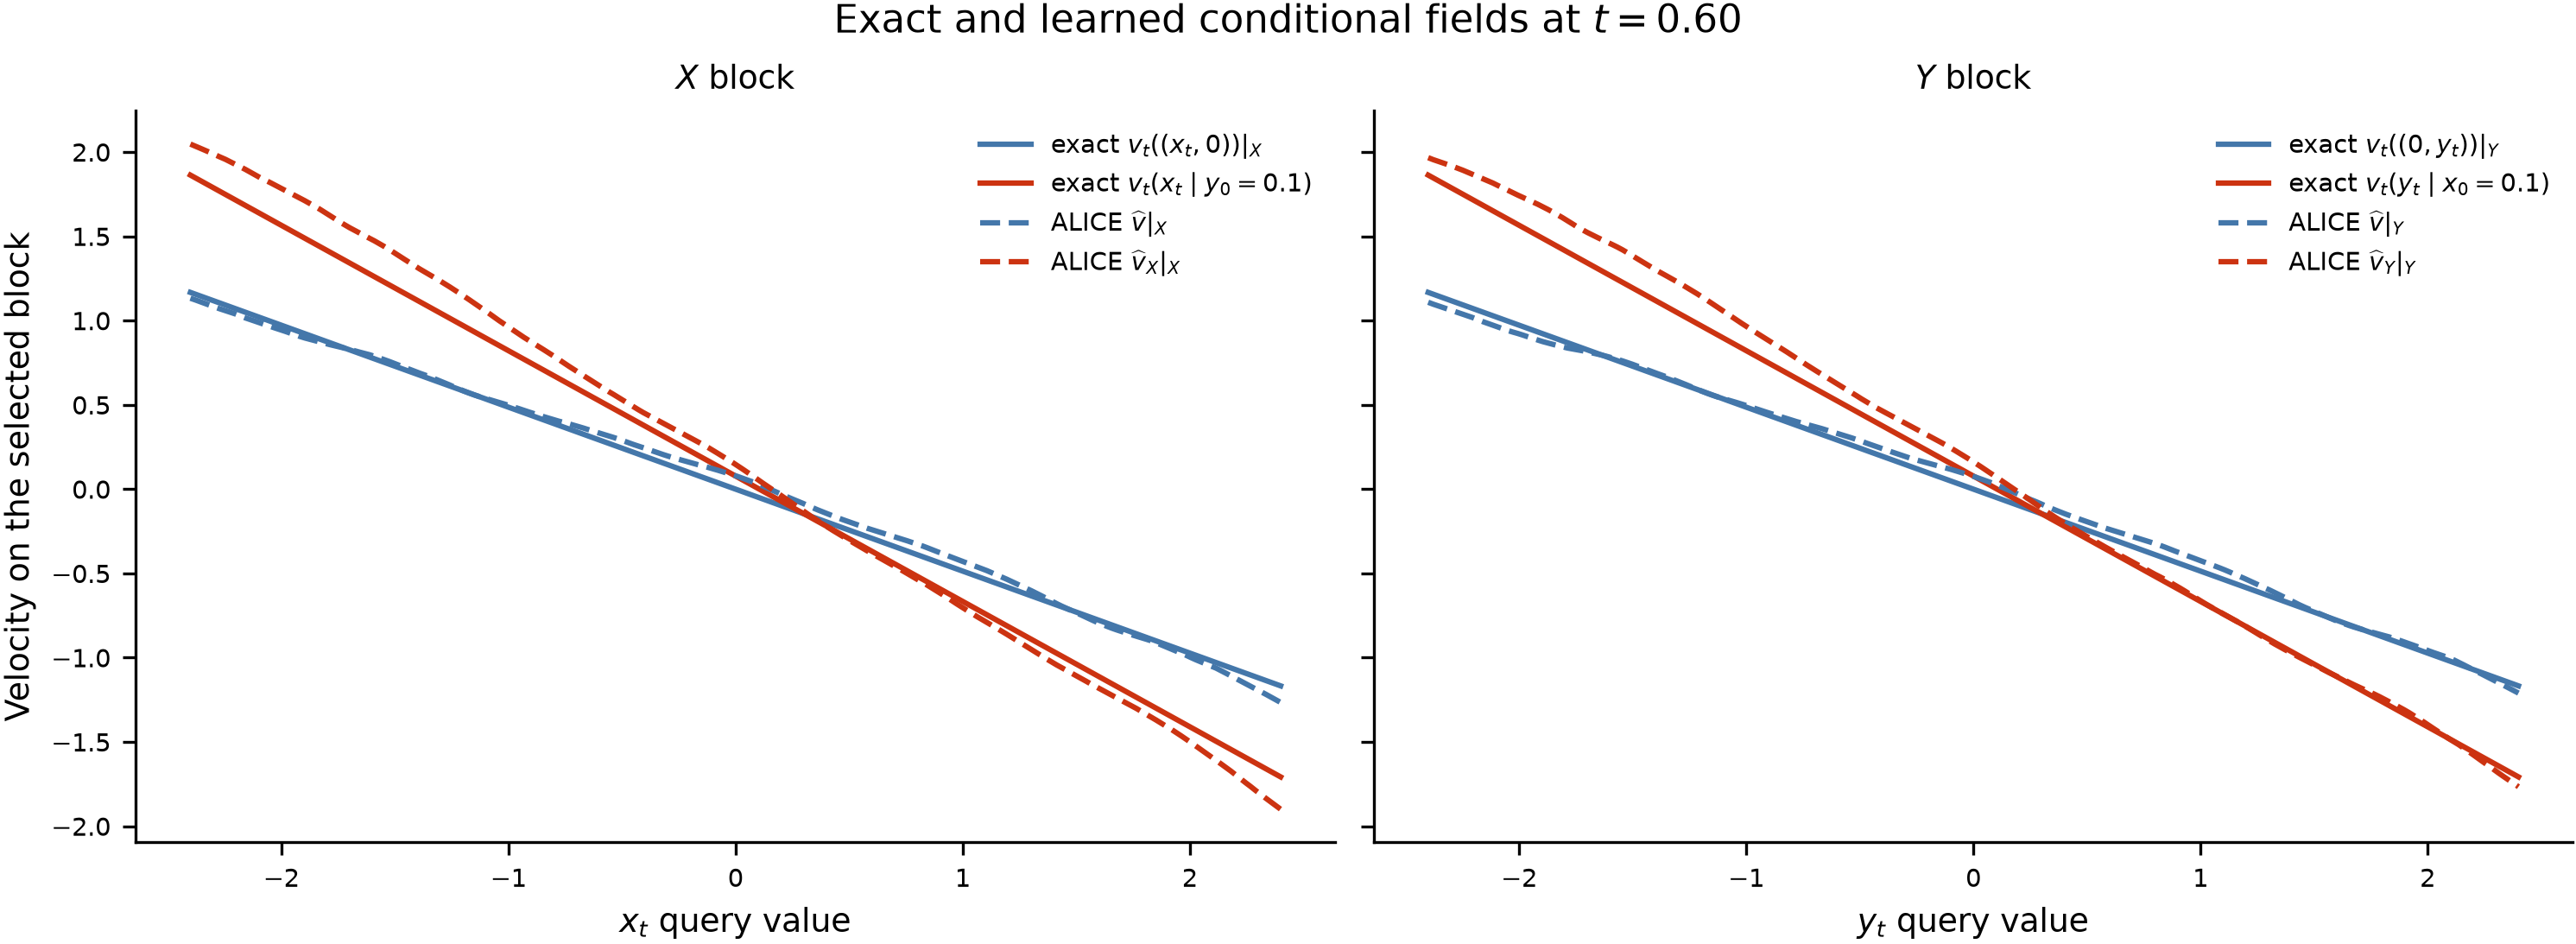

In [21]:
condition = 0.1
curve_grid = torch.linspace(-2.4, 2.4, 220, dtype=model_samples.dtype)
full_x_query = torch.stack((curve_grid, torch.zeros_like(curve_grid)), dim=-1)
cond_x_query = torch.stack((curve_grid, torch.full_like(curve_grid, condition)), dim=-1)
full_y_query = torch.stack((torch.zeros_like(curve_grid), curve_grid), dim=-1)
cond_y_query = torch.stack((torch.full_like(curve_grid, condition), curve_grid), dim=-1)
time_column = torch.full((curve_grid.shape[0], 1), t_field, dtype=curve_grid.dtype)

learned_full_x = field(full_x_query, time_column, m_xy)[:, 0]
learned_cond_x = field(cond_x_query, time_column, m_x)[:, 0]
learned_full_y = field(full_y_query, time_column, m_xy)[:, 1]
learned_cond_y = field(cond_y_query, time_column, m_y)[:, 1]
exact_full_x = exact_joint_velocity(full_x_query, t_field, rho)[:, 0]
exact_cond_x = exact_conditional_velocity(curve_grid, t_field, condition, rho)
exact_full_y = exact_joint_velocity(full_y_query, t_field, rho)[:, 1]
exact_cond_y = exact_conditional_velocity(curve_grid, t_field, condition, rho)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.7), sharey=True, layout='constrained')
axes[0].plot(curve_grid, exact_full_x, color=COLORS['field'],
              label=r'exact $v_t((x_t,0))|_X$')
axes[0].plot(curve_grid, exact_cond_x, color=COLORS['conditional'],
              label=fr'exact $v_t(x_t\mid y_0={condition:.1f})$')
axes[0].plot(curve_grid, learned_full_x, color=COLORS['field'], ls='--',
              label=r'ALICE $\widehat{v}|_X$')
axes[0].plot(curve_grid, learned_cond_x, color=COLORS['conditional'], ls='--',
              label=r'ALICE $\widehat{v}_X|_X$')
axes[0].set(xlabel=r'$x_t$ query value', ylabel='Velocity on the selected block', title=r'$X$ block')
axes[1].plot(curve_grid, exact_full_y, color=COLORS['field'],
              label=r'exact $v_t((0,y_t))|_Y$')
axes[1].plot(curve_grid, exact_cond_y, color=COLORS['conditional'],
              label=fr'exact $v_t(y_t\mid x_0={condition:.1f})$')
axes[1].plot(curve_grid, learned_full_y, color=COLORS['field'], ls='--',
              label=r'ALICE $\widehat{v}|_Y$')
axes[1].plot(curve_grid, learned_cond_y, color=COLORS['conditional'], ls='--',
              label=r'ALICE $\widehat{v}_Y|_Y$')
axes[1].set(xlabel=r'$y_t$ query value', title=r'$Y$ block')
for ax in axes:
    ax.legend(frameon=False, fontsize=7)
fig.suptitle(fr'Exact and learned conditional fields at $t = {t_field:.2f}$')
plt.show()

In [22]:
model_mi = estimate_mi_fast(
    model, torch.cat((model_samples, evaluation_samples)), slice(0, 1), slice(1, 2),
    n_context=n_context, n_eval=n_eval, n_t_samples=64, chunk=1024, device=device,
    generator=torch.Generator().manual_seed(SEED + 3),
    return_std=True, normalize=False,
)
print(f'ALICE estimate I_hat(X;Y) from public API: {model_mi[0]:.4f} +/- {model_mi[1]:.4f} nats')

ALICE estimate I_hat(X;Y) from public API: 0.2763 +/- 0.0018 nats


## Takeaways

1. A velocity field is a function of both the noisy query and the time $t$.
2. The context $C$ identifies the distribution; it is encoded once and reused.
3. The noising indicators $m_{XY}$, $m_X$, and $m_Y$ let one frozen model answer three related questions.
4. Mutual information is the area under the expected, weighted squared gaps between those fields.
5. The ALICE output $v_\theta(z,t,m;C)$ approximates a velocity field; the estimator combines its predictions into $\widehat I(X;Y)$.